**Importación de librerías**

In [1]:
import pandas as pd #Libreria para manipular, limpiar y analizar datos (.csv, .xlsx, SQL, JSON)
import numpy as np #Libreria para realizar cálculos matemáticos sobre arrays
import matplotlib.pyplot as plt #Libreria para Visualizar Dato en gráficos
import seaborn as sns #Libreria que se construye sobre matplotlib para graficos complejos

**Carga del dataset**

In [2]:
df = pd.read_excel('/content/datos_horarios_contaminacion_lima.xlsx')

**Inspección inicial del dataset**

In [3]:
print("Tamaño del dataset:")
print(df.shape)

print("\nColumnas:")
print(df.columns)

print("\nTipos de datos:")
print(df.dtypes)

print("\nPrimeras filas:")
print(df.head())

print("\nÚltimas filas:")
print(df.tail())

Tamaño del dataset:
(703056, 12)

Columnas:
Index(['CODIGO ESTACION', 'ESTACION', 'ANO', 'MES', 'DIA', 'HORA', 'PM 10',
       'PM 2.5', 'SO2', 'NO2', 'O3', 'CO'],
      dtype='object')

Tipos de datos:
CODIGO ESTACION      int64
ESTACION            object
ANO                  int64
MES                  int64
DIA                  int64
HORA                 int64
PM 10              float64
PM 2.5             float64
SO2                float64
NO2                float64
O3                 float64
CO                 float64
dtype: object

Primeras filas:
   CODIGO ESTACION ESTACION   ANO  MES  DIA  HORA   PM 10  PM 2.5   SO2   NO2  \
0           112192      ATE  2010    4    1     0     NaN     NaN  39.8   NaN   
1           112192      ATE  2010    4    1     1  135.69     NaN  29.9  47.2   
2           112192      ATE  2010    4    1     2  135.84     NaN  26.5  44.1   
3           112192      ATE  2010    4    1     3  119.06     NaN  25.9  41.4   
4           112192      ATE  2010    

**Visualización inicial de valores nulos**

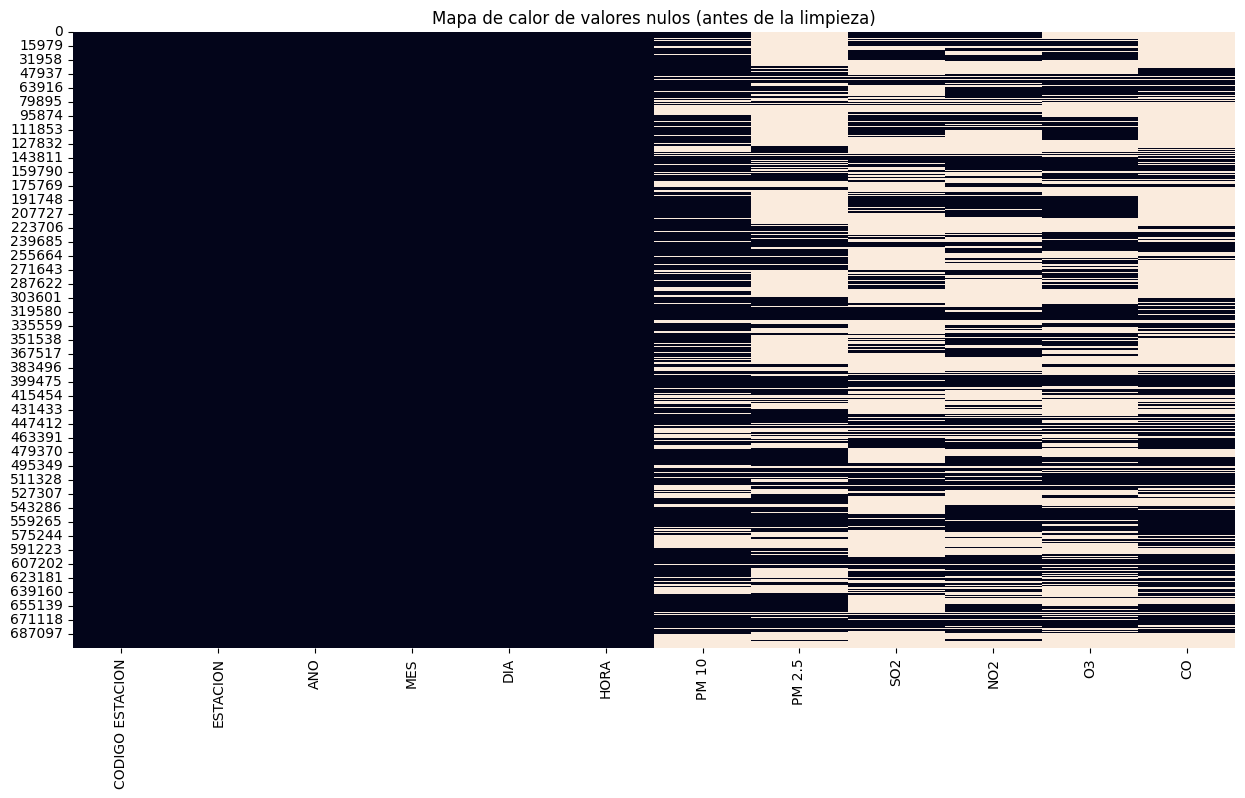

In [4]:
plt.figure(figsize=(15,8))
sns.heatmap(df.isnull(),cbar=False,cmap="rocket")
plt.title("Mapa de calor de valores nulos (antes de la limpieza)")
plt.show()

**Conversión de contaminantes a numéricos**

In [5]:
contaminantes = ["PM 10","PM 2.5","SO2","NO2","O3","CO"]
for col in contaminantes:
    df[col] = (df[col].astype(str).str.replace(",", ".", regex=False))
    df[col] = pd.to_numeric(df[col],errors="coerce")

**Verificar tipos y porcentaje de nulos**

In [6]:
print("\nTipos de datos:")
print(df.dtypes)
print("\nPorcentaje de nulos:")
print((df[contaminantes].isnull().mean()*100).round(2)) #Con mean obtenemos la media y *100 para obtener el porcentaje con dos decimales


Tipos de datos:
CODIGO ESTACION      int64
ESTACION            object
ANO                  int64
MES                  int64
DIA                  int64
HORA                 int64
PM 10              float64
PM 2.5             float64
SO2                float64
NO2                float64
O3                 float64
CO                 float64
dtype: object

Porcentaje de nulos:
PM 10     29.35
PM 2.5    51.64
SO2       58.14
NO2       50.04
O3        50.40
CO        54.29
dtype: float64


**Eliminación de duplicados**

In [7]:
duplicados = df.duplicated(subset=["CODIGO ESTACION","ANO","MES","DIA","HORA"])
print("Duplicados encontrados:",duplicados.sum())

df = df.drop_duplicates(subset=["CODIGO ESTACION","ANO","MES","DIA","HORA"])
print("Duplicados después de eliminar:",df.duplicated(subset=["CODIGO ESTACION","ANO","MES","DIA","HORA"]).sum())

Duplicados encontrados: 9
Duplicados después de eliminar: 0


**Nulos antes de la imputación**

In [8]:
print("ANTES DE LA IMPUTACIÓN:")
print((df[contaminantes].isnull().mean()*100).round(2))

ANTES DE LA IMPUTACIÓN:
PM 10     29.35
PM 2.5    51.64
SO2       58.14
NO2       50.04
O3        50.40
CO        54.29
dtype: float64


**Interpolación temporal (lineal)**

In [9]:
for col in contaminantes:
    df[col] = df.groupby("CODIGO ESTACION")[col].transform(lambda x: x.interpolate(method="linear",limit=6,limit_direction="both"))
print("DESPUÉS DEL NIVEL 1:")
print((df[contaminantes].isnull().mean()*100).round(2))

DESPUÉS DEL NIVEL 1:
PM 10     28.24
PM 2.5    50.64
SO2       57.18
NO2       48.73
O3        49.19
CO        53.27
dtype: float64


**Mediana por estación + hora**

In [10]:
for col in contaminantes:
    df[col] = df[col].fillna( df.groupby(["CODIGO ESTACION","HORA"])[col].transform("median"))
print("DESPUÉS DEL NIVEL 2:")
print((df[contaminantes].isnull().mean()*100).round(2))

DESPUÉS DEL NIVEL 2:
PM 10     0.0
PM 2.5    0.0
SO2       0.0
NO2       0.0
O3        0.0
CO        0.0
dtype: float64


**Heatmap después de la imputación**

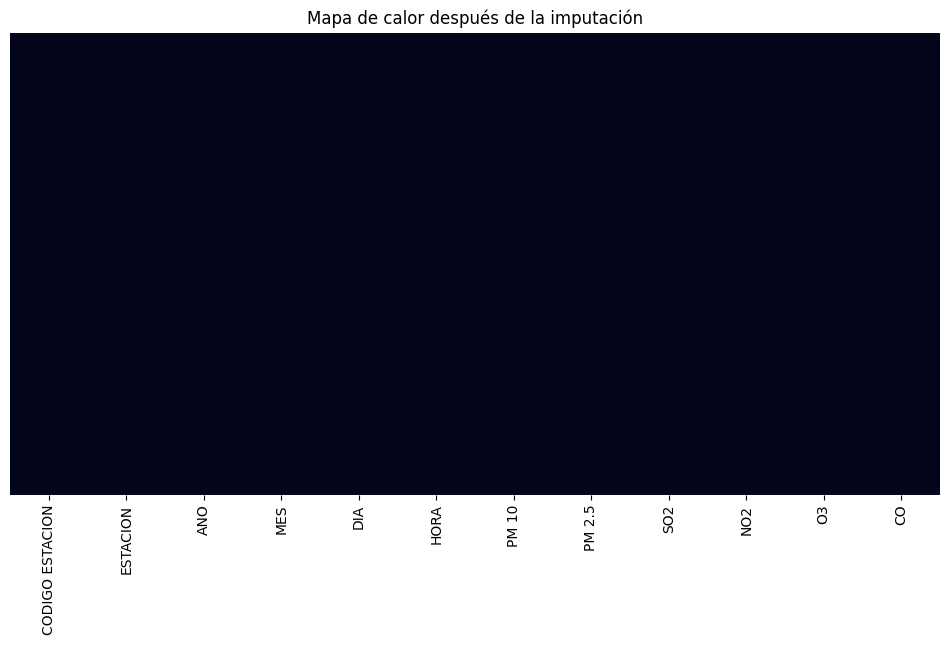

In [11]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(),cbar=False,yticklabels=False)
plt.title("Mapa de calor después de la imputación")
plt.show()

**Validacion**




In [12]:
print("Nulos finales:")
print(df[contaminantes].isnull().sum())

Nulos finales:
PM 10     0
PM 2.5    0
SO2       0
NO2       0
O3        0
CO        0
dtype: int64


**Encontramos una fila con todos los valores nulos (eliminamos)**

In [13]:
df[df[contaminantes].isnull().any(axis=1)]

,CODIGO ESTACION,ESTACION,ANO,MES,DIA,HORA,PM 10,PM 2.5,SO2,NO2,O3,CO


In [14]:
df = df.dropna(subset=contaminantes)
print(df[contaminantes].isnull().sum())

PM 10     0
PM 2.5    0
SO2       0
NO2       0
O3        0
CO        0
dtype: int64


Graficas de la Investigación

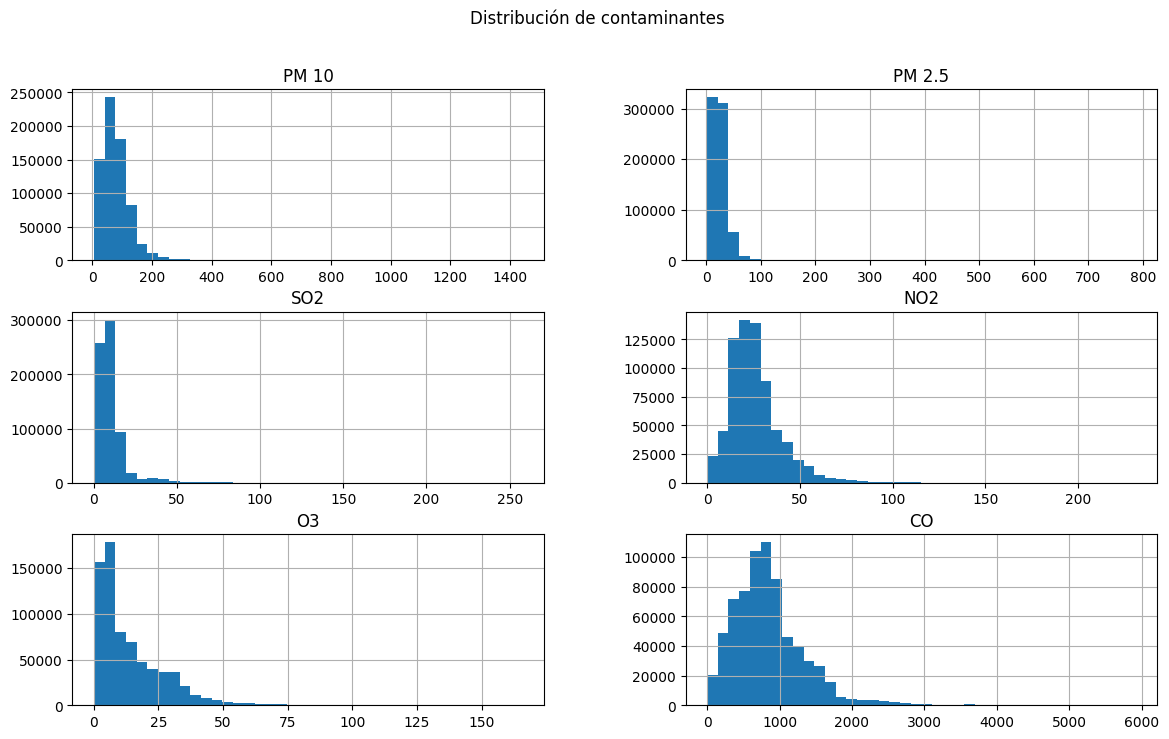

In [15]:
contaminantes = ["PM 10","PM 2.5","SO2","NO2","O3","CO"]
df[contaminantes].hist(figsize=(14,8),bins=40)
plt.suptitle("Distribución de contaminantes")
plt.show()

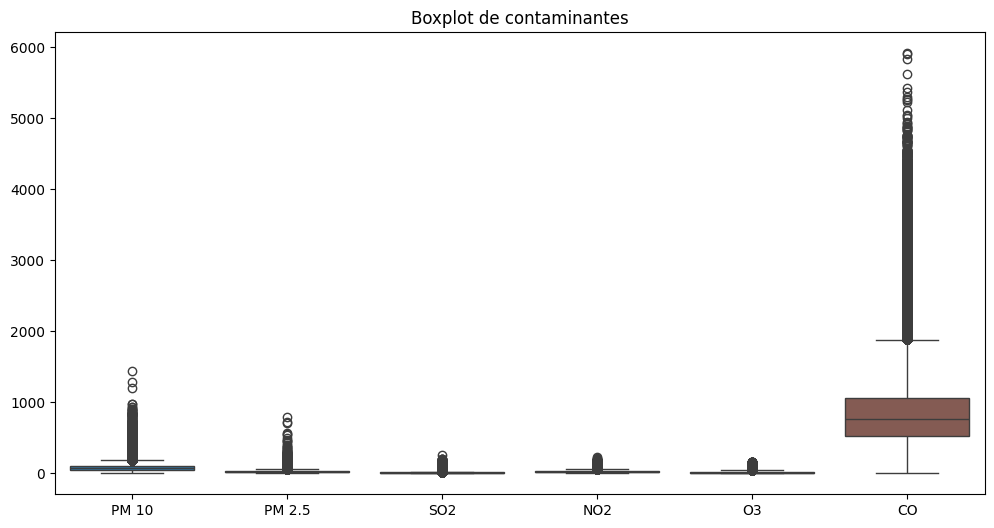

In [16]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[contaminantes])
plt.title("Boxplot de contaminantes")
plt.show()

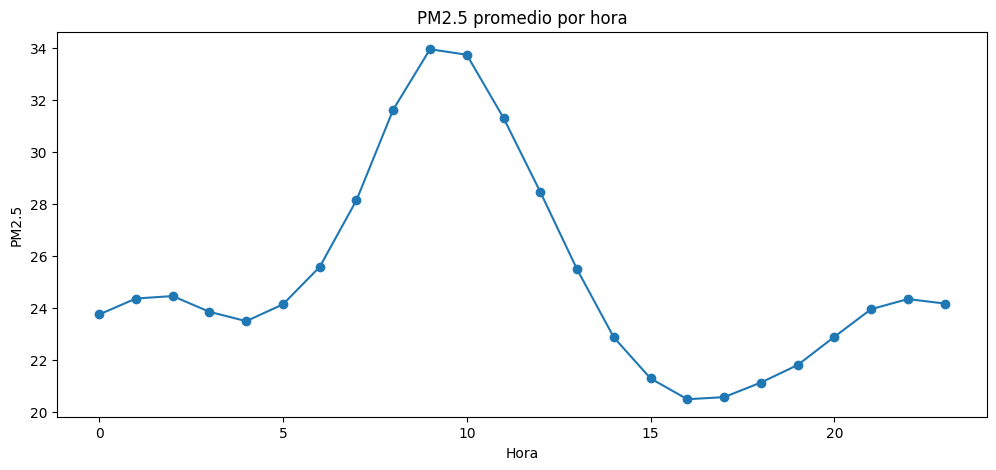

In [17]:
plt.figure(figsize=(12,5))
df.groupby("HORA")["PM 2.5"].mean().plot(marker="o")
plt.title("PM2.5 promedio por hora")
plt.xlabel("Hora")
plt.ylabel("PM2.5")
plt.show()

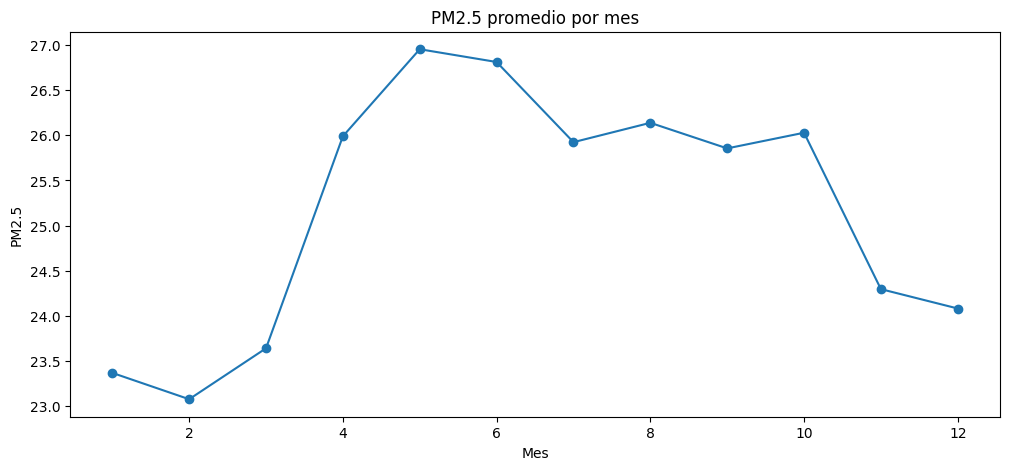

In [18]:
plt.figure(figsize=(12,5))
df.groupby("MES")["PM 2.5"].mean().plot(marker="o")
plt.title("PM2.5 promedio por mes")
plt.xlabel("Mes")
plt.ylabel("PM2.5")
plt.show()

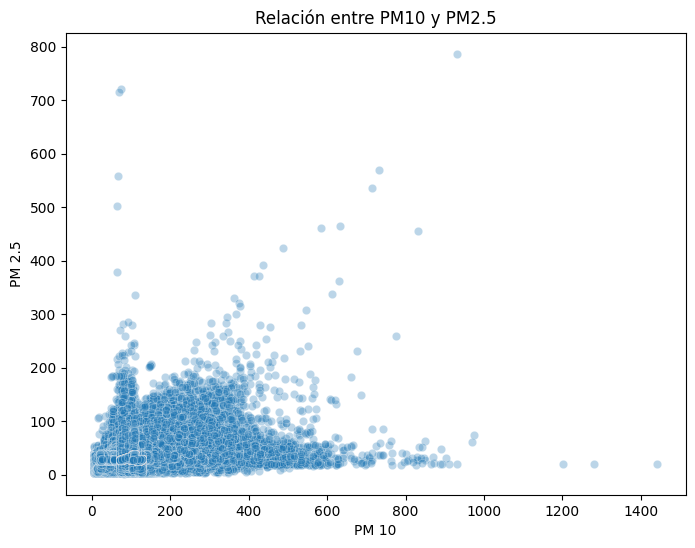

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x="PM 10",y="PM 2.5",alpha=0.3)
plt.title("Relación entre PM10 y PM2.5")
plt.show()

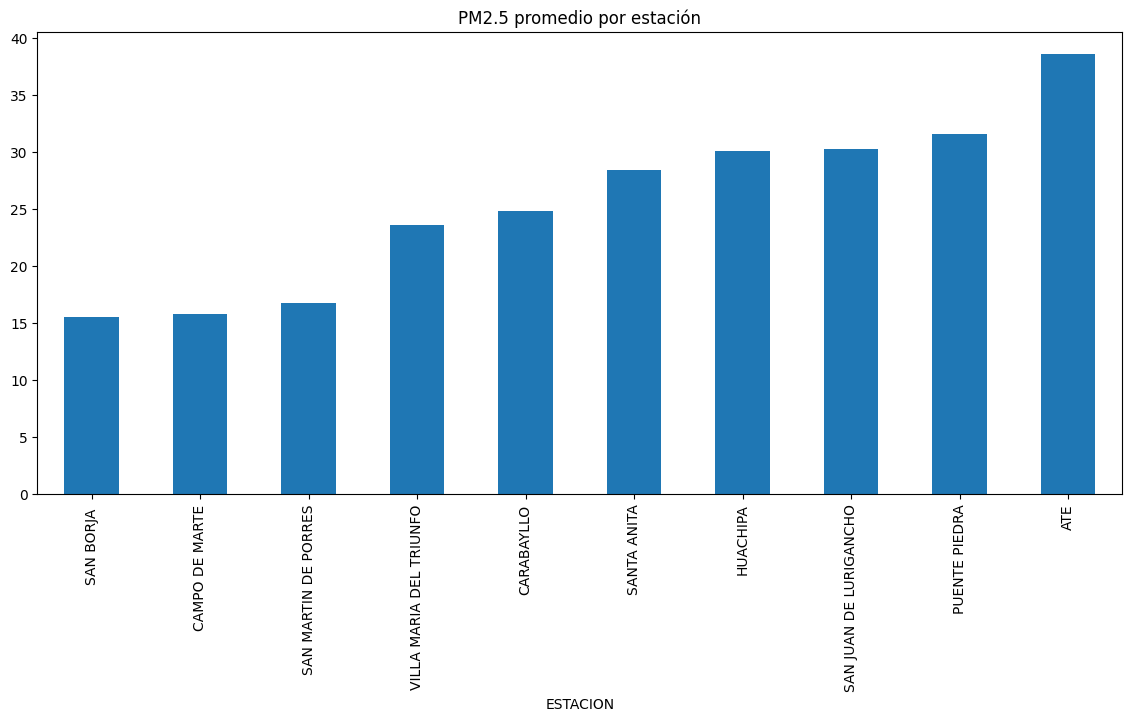

In [20]:
plt.figure(figsize=(14,6))
df.groupby("ESTACION")["PM 2.5"].mean().sort_values().plot(kind="bar")
plt.title("PM2.5 promedio por estación")
plt.show()

In [21]:
df.to_excel('datos_horarios_contaminacion_lima_limpio.xlsx', index=False)
print("Dataset limpio guardado como 'datos_horarios_contaminacion_lima_limpio.xlsx'")

Dataset limpio guardado como 'datos_horarios_contaminacion_lima_limpio.xlsx'
